# 아산시 방송효과 통합 분석

**목적**: 9개 방송 전체에 대해 동일한 인과추론 엔진을 적용하고, 효과가
**출연자 유형(가수/개그맨/아나운서 등)·프로그램 장르(예능/교양/음악 등)**에
따라 어떻게 달라지는지를 분석한다.

**설계 원칙**
1. 특정 방송(뛰어야산다 등)에 편중하지 않는다 — 모든 방송을 같은 틀로 처리.
2. 방송마다 데이터·시점·촬영지가 다르므로 `run_broadcast(방송ID)` 한 함수로 일반화.
3. 효과 크기를 종속변수로, 방송 특성을 설명변수로 하는 **조절효과(메타) 회귀**가 핵심.

**3대 결과변수**
- 돈: BC카드 외지인 소비 (주 단위) — 주력
- 차: T맵 목적지 방문 (일 단위) — 단기효과
- 사람: SKT 유입인구 (월/일) — 보조 (커버리지 짧음)

**방법**: CausalImpact(고립 방송) + Staggered DID(겹친 방송) 교차검증.


## 0. 공통 설정 & 헬퍼

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

from config import (BROADCAST_DIR, CARD_DIR, TMAP_DIR, POP_DIR,
                    BROADCAST_DONG_MAP, ALL_TREATED_DONGS, CARD_FILE_PATTERNS,
                    read_csv_auto, load_monthly_data, classify_tourism)
from causal_utils import SimpleCausalImpact, run_did, staggered_did, plot_event_study

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
# ---- 주차코드(YYYYWW) → 주 시작일(월요일) : 규칙 자동 감지 ----
def week_to_monday(week_code, ym_code=None):
    """CRTR_WEEK가 연중누적 ISO주인지 월내주차인지 모를 때 둘 다 시도."""
    if pd.isna(week_code):
        return pd.NaT
    s = str(int(week_code))
    if len(s) < 6:
        return pd.NaT
    yy, ww = int(s[:4]), int(s[4:])
    if 1 <= ww <= 53:
        try:
            return pd.Timestamp(dt.date.fromisocalendar(yy, ww, 1))
        except ValueError:
            pass
    if ym_code is not None and not pd.isna(ym_code):
        ym = str(int(ym_code))
        try:
            base = dt.date(int(ym[:4]), int(ym[4:6]), 1)
            return pd.Timestamp(base + dt.timedelta(days=(max(ww, 1) - 1) * 7))
        except Exception:
            return pd.NaT
    return pd.NaT


def to_int_str(series):
    """float로 읽힌 코드 컬럼의 .0 제거하여 문자열화."""
    return series.astype('Int64').astype(str)

## 1. 방송 메타데이터 + 특성 인코딩

`broadcast_data`(장르·시청률·방영일)와 `broadcast_cast`(출연자 유형·인지도)를
합쳐, 각 방송의 **특성 벡터**를 만든다. 이것이 나중에 효과의 조절변수가 된다.


In [3]:
broadcast = read_csv_auto(BROADCAST_DIR / 'broadcast_data.csv')
cast = read_csv_auto(BROADCAST_DIR / 'broadcast_cast.csv')
locations = read_csv_auto(BROADCAST_DIR / 'broadcast_locations.csv')

print("방송:", broadcast['프로그램명'].tolist())
print("\n출연자 유형 분포:")
print(cast['연예인유형'].value_counts())

방송: ['전국노래자랑 아산시편', '전현무계획2', '굿모닝 대한민국', '6시 내고향', '박원숙의 같이삽시다 시즌3', '뛰어야산다2', '황제성의 황제파워', '비긴어게인', '구해줘홈즈']

출연자 유형 분포:
연예인유형
트로트가수        5
개그맨          3
개그맨/MC       1
유튜버(곽튜브)     1
배우           1
가수/배우        1
가수/방송인       1
전축구선수/방송인    1
아나운서/방송인     1
아이돌(비스트)     1
가수           1
Name: count, dtype: int64


In [4]:
# ---- 방영일 파싱 (확정된 방송만 실측 대상) ----
def parse_air_date(s):
    s = str(s).strip()
    try:
        return pd.to_datetime(s[:10])     # YYYY-MM-DD
    except Exception:
        pass
    if len(s) >= 7 and s[4] == '-':       # 2026-06~07 → 월 1일
        try:
            return pd.to_datetime(s[:7] + '-01')
        except Exception:
            return pd.NaT
    return pd.NaT

broadcast['air_date'] = broadcast['방영일'].apply(parse_air_date)

# 실측 가능 여부: 방영일 확정 + 데이터 커버리지(카드/T맵 ~2026-04) 안
DATA_END = pd.Timestamp('2026-04-30')
broadcast['confirmed'] = broadcast['air_date'].notna()
broadcast['measurable'] = broadcast['confirmed'] & (broadcast['air_date'] <= DATA_END)

print("실측 가능 방송:")
print(broadcast.loc[broadcast['measurable'], ['프로그램명', 'air_date', '장르', '시청률_pct']])
print("\n사전평가만 가능(미방영/데이터밖):")
print(broadcast.loc[~broadcast['measurable'], ['프로그램명', '방영일', '장르']])

실측 가능 방송:
            프로그램명   air_date          장르  시청률_pct
0     전국노래자랑 아산시편 2025-06-08        음악예능     6.50
1          전현무계획2 2025-11-07     여행버라이어티     1.50
2        굿모닝 대한민국 2025-11-12        교양정보     0.55
3          6시 내고향 2025-11-13        교양정보     5.50
4  박원숙의 같이삽시다 시즌3 2025-11-24          예능     3.00
5          뛰어야산다2 2026-01-12  스포츠리얼버라이어티     1.50

사전평가만 가능(미방영/데이터밖):
       프로그램명         방영일       장르
6  황제성의 황제파워  2026-05-09  라디오공개방송
7      비긴어게인  2026-06~07     음악예능
8      구해줘홈즈  2026-09~10    부동산예능


In [5]:
# ---- 출연자 특성 집계: 방송별 대표 유형 + 최고 인지도 ----
# 인지도 등급 S>A>B>C 를 점수화
grade_score = {'S': 4, 'A': 3, 'B': 2, 'C': 1}
cast['인지도점수'] = cast['인지도_등급'].map(grade_score)

def simplify_type(t):
    """세부 유형을 큰 범주로. (가수/개그맨/아나운서/배우/유튜버/스포츠/기타)"""
    t = str(t)
    if '트로트' in t or '가수' in t: return '가수'
    if '개그' in t or 'MC' in t:     return '개그맨/MC'
    if '아나운서' in t:              return '아나운서'
    if '배우' in t:                  return '배우'
    if '유튜버' in t:                return '유튜버'
    if '축구' in t or '선수' in t:   return '스포츠인'
    return '기타'

cast['유형범주'] = cast['연예인유형'].apply(simplify_type)

cast_agg = cast.groupby('프로그램명').agg(
    출연자수=('출연자명', 'count'),
    최고인지도=('인지도점수', 'max'),
    평균인지도=('인지도점수', 'mean'),
    대표유형=('유형범주', lambda x: x.mode().iloc[0] if len(x.mode()) else '기타'),
    유형목록=('유형범주', lambda x: ', '.join(sorted(x.dropna().unique()))),
).reset_index()

print(cast_agg)

            프로그램명  출연자수  최고인지도  평균인지도    대표유형                        유형목록
0          6시 내고향     1    NaN    NaN      기타                          기타
1        굿모닝 대한민국     1    NaN    NaN      기타                          기타
2          뛰어야산다2     5   3.00   3.00      가수  가수, 개그맨/MC, 기타, 스포츠인, 아나운서
3  박원숙의 같이삽시다 시즌3     2   3.00   3.00      가수                      가수, 배우
4     전국노래자랑 아산시편     5   3.00   2.00      가수                          가수
5          전현무계획2     2   4.00   3.50  개그맨/MC                 개그맨/MC, 유튜버
6       황제성의 황제파워     3   2.00   2.00  개그맨/MC                  가수, 개그맨/MC


In [6]:
# ---- 방송 특성 테이블 = 메타 회귀의 설계행렬 기반 ----
def simplify_genre(g):
    g = str(g)
    if '음악' in g:                      return '음악예능'
    if '여행' in g or '버라이어티' in g: return '여행예능'
    if '교양' in g or '정보' in g:       return '교양정보'
    if '예능' in g:                      return '예능'
    if '라디오' in g:                    return '라디오'
    return '기타'

broadcast['장르범주'] = broadcast['장르'].apply(simplify_genre)

bmeta = broadcast[['프로그램명', '연도', '방송사', '장르범주', '방송유형',
                   'air_date', '시청률_pct', 'measurable']].merge(
    cast_agg, on='프로그램명', how='left')

# 촬영 읍면동 수(노출 범위)도 특성
loc_cnt = locations.groupby('프로그램명')['읍면동'].nunique().rename('노출읍면동수')
bmeta = bmeta.merge(loc_cnt, on='프로그램명', how='left')

bmeta['출연자수'] = bmeta['출연자수'].fillna(0)
bmeta['최고인지도'] = bmeta['최고인지도'].fillna(0)
print("=== 방송 특성 테이블 (조절변수) ===")
display(bmeta)

=== 방송 특성 테이블 (조절변수) ===


,프로그램명,연도,방송사,장르범주,방송유형,air_date,시청률_pct,measurable,출연자수,최고인지도,평균인지도,대표유형,유형목록,노출읍면동수
0,전국노래자랑 아산시편,2025,KBS,음악예능,녹화방송,2025-06-08,6.50,True,5.00,3.00,2.00,가수,가수,1.00
1,전현무계획2,2025,MBN,여행예능,녹화방송,2025-11-07,1.50,True,2.00,4.00,3.50,개그맨/MC,"개그맨/MC, 유튜버",1.00
2,굿모닝 대한민국,2025,KBS,교양정보,녹화방송,2025-11-12,0.55,True,1.00,0.00,NaN,기타,기타,3.00
3,6시 내고향,2025,KBS,교양정보,생방송,2025-11-13,5.50,True,1.00,0.00,NaN,기타,기타,1.00
4,박원숙의 같이삽시다 시즌3,2025,KBS,예능,녹화방송,2025-11-24,3.00,True,2.00,3.00,3.00,가수,"가수, 배우",6.00
5,뛰어야산다2,2025,MBN,여행예능,녹화방송,2026-01-12,1.50,True,5.00,3.00,3.00,가수,"가수, 개그맨/MC, 기타, 스포츠인, 아나운서",2.00
6,황제성의 황제파워,2026,SBS,라디오,녹화방송,2026-05-09,NaN,False,3.00,2.00,2.00,개그맨/MC,"가수, 개그맨/MC",1.00
7,비긴어게인,2026,JTBC,음악예능,녹화방송,2026-06-01,NaN,False,0.00,0.00,NaN,NaN,NaN,NaN
8,구해줘홈즈,2026,MBC,예능,녹화방송,2026-09-01,NaN,False,0.00,0.00,NaN,NaN,NaN,NaN


## 2. 공통 분석 엔진

방송 하나를 받아 (1) 촬영 읍면동을 처치군으로, (2) 그 외를 통제군으로 잡고,
(3) 방영일 기준 pre/post를 구성해 CausalImpact·DID를 돌리는 함수.
**모든 방송에 동일 적용**되므로 특정 방송 편중이 없다.


In [7]:
# 방송명 → 촬영 읍면동 (config의 매핑 사용, 없으면 locations에서 보강)
def get_treated_dongs(program_name):
    dongs = BROADCAST_DONG_MAP.get(program_name)
    if dongs:
        return list(dongs)
    sub = locations.loc[locations['프로그램명'] == program_name, '읍면동'].dropna()
    out = []
    for v in sub:
        out += [d.strip() for d in str(v).split(',') if d.strip() and d != '복수']
    return sorted(set(out))

# 방영일 매핑 (확정 방송)
AIR = dict(zip(broadcast['프로그램명'], broadcast['air_date']))

for _, r in bmeta.iterrows():
    print(f"{r['프로그램명']:20} | {r['장르범주']:8} | 대표유형={r.get('대표유형','-'):8} "
          f"| 촬영동={get_treated_dongs(r['프로그램명'])}")

전국노래자랑 아산시편          | 음악예능     | 대표유형=가수       | 촬영동=['온천동']
전현무계획2               | 여행예능     | 대표유형=개그맨/MC   | 촬영동=[]
굿모닝 대한민국             | 교양정보     | 대표유형=기타       | 촬영동=['온천동', '염치읍', '신창면']
6시 내고향               | 교양정보     | 대표유형=기타       | 촬영동=[]
박원숙의 같이삽시다 시즌3       | 예능       | 대표유형=가수       | 촬영동=['염치읍', '온천동', '영인면', '송악면']
뛰어야산다2               | 여행예능     | 대표유형=가수       | 촬영동=['온천동', '염치읍']
황제성의 황제파워            | 라디오      | 대표유형=개그맨/MC   | 촬영동=['온천동']
비긴어게인                | 음악예능     | 대표유형=     nan | 촬영동=[]
구해줘홈즈                | 예능       | 대표유형=     nan | 촬영동=[]


In [8]:
def build_weekly_panel(df, dong_col, amt_col):
    """카드류 df → (읍면동 x 주) 패널. week_start(실제 날짜) 포함."""
    df = df.copy()
    df['YM'] = to_int_str(df['CRTR_YM'])
    df['period'] = to_int_str(df['CRTR_WEEK'])
    df = df[~df['period'].isin(['<NA>', 'nan'])]
    df['week_start'] = [week_to_monday(w, y) for w, y in
                        zip(df['CRTR_WEEK'].astype('Int64'), df['CRTR_YM'].astype('Int64'))]
    df = df[df['week_start'].notna()]
    panel = (df.groupby([dong_col, 'period', 'week_start'])[amt_col]
               .sum().reset_index())
    return panel


def run_broadcast(panel, dong_col, amt_col, program_name, treated_dongs,
                  air_date, pre_weeks=12, post_weeks=8, verbose=True):
    """한 방송에 대해 CausalImpact + DID 실행 → 효과 dict 반환."""
    if pd.isna(air_date):
        return {'프로그램명': program_name, 'status': 'no_air_date'}

    # 처치/통제 라벨
    p = panel.copy()
    p['treated'] = p[dong_col].apply(
        lambda x: 1 if any(t in str(x) for t in treated_dongs) else 0)
    if p['treated'].sum() == 0:
        return {'프로그램명': program_name, 'status': 'no_treated_match',
                'treated_dongs': treated_dongs}

    # pre/post 윈도 (방영일 기준 주 단위)
    wk = pd.Timedelta(weeks=1)
    pre_s, pre_e = air_date - pre_weeks * wk, air_date - wk
    post_s, post_e = air_date, air_date + post_weeks * wk

    # ---- 시계열(처치 합계 vs 통제 합계) ----
    ts = (p.groupby(['week_start', 'treated'])[amt_col].sum()
            .unstack('treated').fillna(0).sort_index())
    ts.columns = ['control' if c == 0 else 'treated' for c in ts.columns]
    if 'treated' not in ts or 'control' not in ts:
        return {'프로그램명': program_name, 'status': 'missing_group'}

    win = ts[(ts.index >= pre_s) & (ts.index <= post_e)]
    pre_idx = win.index[win.index < air_date]
    post_idx = win.index[win.index >= air_date]
    if len(pre_idx) < 3 or len(post_idx) < 2:
        return {'프로그램명': program_name, 'status': 'insufficient_periods',
                'n_pre': len(pre_idx), 'n_post': len(post_idx)}

    res = {'프로그램명': program_name, 'status': 'ok',
           'n_pre': len(pre_idx), 'n_post': len(post_idx),
           'air_date': air_date, 'treated_dongs': treated_dongs}

    # ---- CausalImpact ----
    try:
        ci_df = pd.DataFrame({'y': win['treated'].values,
                              'x1': win['control'].values})
        n_pre = len(pre_idx)
        ci = SimpleCausalImpact(ci_df, pre_period=[0, n_pre - 1],
                                post_period=[n_pre, len(win) - 1])
        s = ci.summary_stats
        res.update(CI_절대효과=s['absolute_effect'],
                   CI_상대효과=s['relative_effect_pct'],
                   CI_p값=s['p_value'], CI_유의=bool(s['significant']),
                   _ci=ci, _win=win, _air=air_date)
    except Exception as e:
        res['CI_error'] = str(e)

    # ---- DID 교차검증 ----
    try:
        d = p[(p['week_start'] >= pre_s) & (p['week_start'] <= post_e)].copy()
        d['post'] = (d['week_start'] >= air_date).astype(int)
        did = run_did(d, amt_col, 'treated', 'post', cluster_col=dong_col)
        res.update(DID_추정치=did['did_coef'], DID_p값=did['did_pvalue'],
                   DID_유의=bool(did['significant']))
    except Exception as e:
        res['DID_error'] = str(e)

    if verbose:
        print(f"[{program_name}] pre={res['n_pre']}주 post={res['n_post']}주 "
              f"CI효과={res.get('CI_상대효과', np.nan):.1f}% "
              f"(p={res.get('CI_p값', np.nan):.3f}) "
              f"DID={res.get('DID_추정치', np.nan):,.0f}")
    return res

## 3. BC카드 외지인 소비 — 전 방송 일괄 분석 (주력)

외지인 정의 = `EXCL_RSDT`(거주자 제외), 지역 키 = `FRCS_DONG_NM`(가맹점 위치).


In [9]:
df_main = load_monthly_data(CARD_DIR, CARD_FILE_PATTERNS['main'])
print("로드:", df_main.shape)

dong_candidates = [c for c in df_main.columns if 'FRCS' in c and 'DONG' in c and 'NM' in c]
dong_col = dong_candidates[0] if dong_candidates else 'FRCS_DONG_NM'
amt_col = 'ALL_USE_AMT' if 'ALL_USE_AMT' in df_main.columns else \
          [c for c in df_main.columns if 'AMT' in c.upper()][0]
print("지역 키:", dong_col, "| 매출 컬럼:", amt_col)

card_panel = build_weekly_panel(df_main, dong_col, amt_col)
print("패널:", card_panel.shape,
      "| 기간:", card_panel['week_start'].min().date(),
      "~", card_panel['week_start'].max().date())
print("읍면동:", sorted(card_panel[dong_col].dropna().unique()))

로드: (541322, 41)
지역 키: FRCS_DONG_NM | 매출 컬럼: ALL_USE_AMT
패널: (1156, 4) | 기간: 2024-12-30 ~ 2026-04-13
읍면동: ['도고면', '둔포면', '배방읍', '선장면', '송악면', '신창면', '염치읍', '영인면', '온양1동', '온양2동', '온양3동', '온양4동', '온양5동', '온양6동', '음봉면', '인주면', '탕정면']


In [10]:
# ---- 모든 측정가능 방송에 엔진 일괄 적용 ----
card_results = []
for _, r in bmeta[bmeta['measurable']].iterrows():
    pname = r['프로그램명']
    res = run_broadcast(card_panel, dong_col, amt_col, pname,
                        get_treated_dongs(pname), AIR.get(pname))
    res['결과변수'] = 'card_외지인소비'
    card_results.append(res)

card_eff = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                         for r in card_results])
print("\n=== 카드 매출 방송별 효과 ===")
display(card_eff[['프로그램명', 'status', 'n_pre', 'n_post',
                  'CI_상대효과', 'CI_p값', 'CI_유의',
                  'DID_추정치', 'DID_유의']])

[굿모닝 대한민국] pre=12주 post=8주 CI효과=-10.2% (p=0.051) DID=-10,329,126
[박원숙의 같이삽시다 시즌3] pre=12주 post=9주 CI효과=-24.2% (p=0.000) DID=-18,945,243
[뛰어야산다2] pre=12주 post=9주 CI효과=-19.2% (p=0.046) DID=-13,373,112

=== 카드 매출 방송별 효과 ===


C:\Users\admin\IdeaProjects\tmoney\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


,프로그램명,status,n_pre,n_post,CI_상대효과,CI_p값,CI_유의,DID_추정치,DID_유의
0,전국노래자랑 아산시편,no_treated_match,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,전현무계획2,no_treated_match,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,굿모닝 대한민국,ok,12.00,8.00,-10.15,0.05,False,"-10,329,125.81",False
3,6시 내고향,no_treated_match,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,박원숙의 같이삽시다 시즌3,ok,12.00,9.00,-24.22,0.00,True,"-18,945,243.44",False
5,뛰어야산다2,ok,12.00,9.00,-19.15,0.05,True,"-13,373,111.55",True


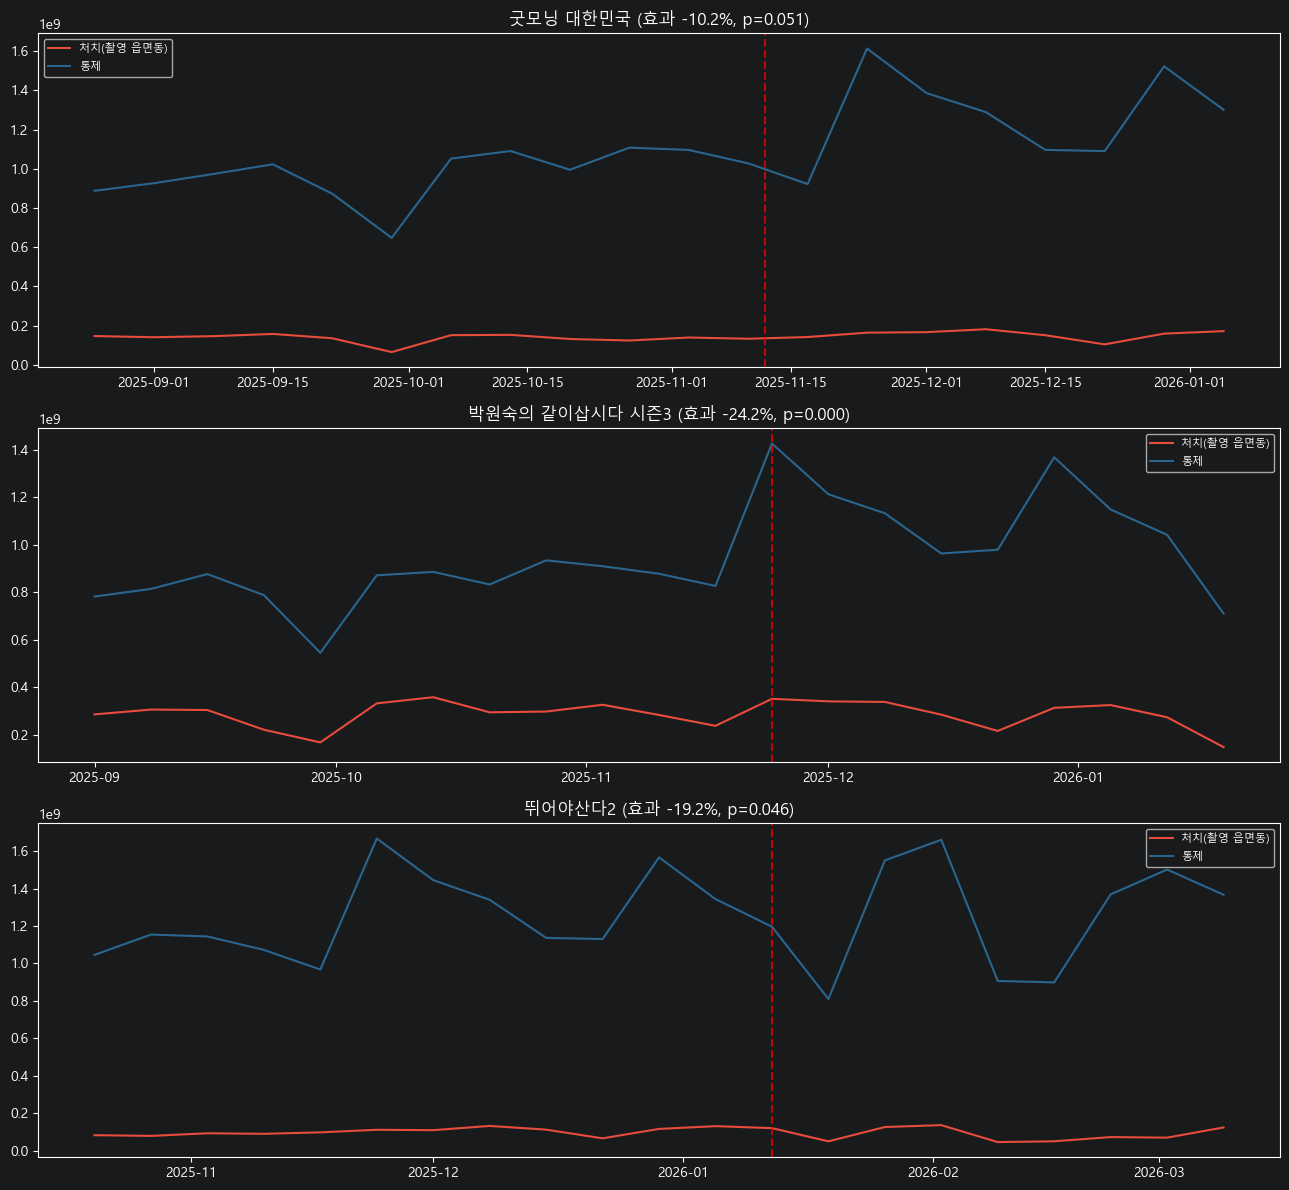

In [11]:
# ---- 정상 추정된 방송들의 CausalImpact 플롯 ----
ok = [r for r in card_results if r.get('status') == 'ok' and '_ci' in r]
if ok:
    fig, axes = plt.subplots(len(ok), 1, figsize=(13, 4 * len(ok)))
    if len(ok) == 1:
        axes = [axes]
    for ax, r in zip(axes, ok):
        win, air = r['_win'], r['_air']
        ax.plot(win.index, win['treated'], color='#e74c3c', label='처치(촬영 읍면동)')
        ax.plot(win.index, win['control'], color='#3498db', alpha=0.6, label='통제')
        ax.axvline(air, color='red', ls='--', alpha=0.7)
        ax.set_title(f"{r['프로그램명']} (효과 {r.get('CI_상대효과', np.nan):.1f}%, "
                     f"p={r.get('CI_p값', np.nan):.3f})")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("정상 추정된 방송 없음 — status 컬럼 확인")

## 4. Staggered DID — 11월 겹친 방송 통합 처리

11월에 4개가 몰려 개별 분리가 안 되므로, 노출 시점이 다른 코호트로 통합 추정한다.


In [12]:
# 각 읍면동의 첫 노출일
dong_first = {}
for _, r in bmeta[bmeta['measurable']].iterrows():
    air = AIR.get(r['프로그램명'])
    if pd.isna(air):
        continue
    for d in get_treated_dongs(r['프로그램명']):
        if d not in dong_first or air < dong_first[d]:
            dong_first[d] = air

print("읍면동별 첫 노출일:")
for d, a in sorted(dong_first.items(), key=lambda x: x[1]):
    print(f"  {d}: {a.date()}")

# time_idx + 처치시점(날짜 이후 첫 주)
ordered = (card_panel[['period', 'week_start']].drop_duplicates()
           .sort_values('week_start').reset_index(drop=True))
ordered['time_idx'] = range(len(ordered))
card_panel2 = card_panel.merge(ordered[['period', 'time_idx']], on='period', how='left')

def date_to_tidx(air):
    after = ordered[ordered['week_start'] >= air]
    return int(after.iloc[0]['time_idx']) if len(after) else np.nan

def treat_time(name):
    best = None
    for d, air in dong_first.items():
        if d in str(name):
            ti = date_to_tidx(air)
            if pd.notna(ti) and (best is None or ti < best):
                best = ti
    return best if best is not None else np.nan

card_panel2['treatment_time'] = card_panel2[dong_col].apply(treat_time)
print("\n처치군:", card_panel2.loc[card_panel2['treatment_time'].notna(), dong_col].nunique(),
      "통제군:", card_panel2.loc[card_panel2['treatment_time'].isna(), dong_col].nunique())

읍면동별 첫 노출일:
  온천동: 2025-06-08
  염치읍: 2025-11-12
  신창면: 2025-11-12
  영인면: 2025-11-24
  송악면: 2025-11-24

처치군: 4 통제군: 13


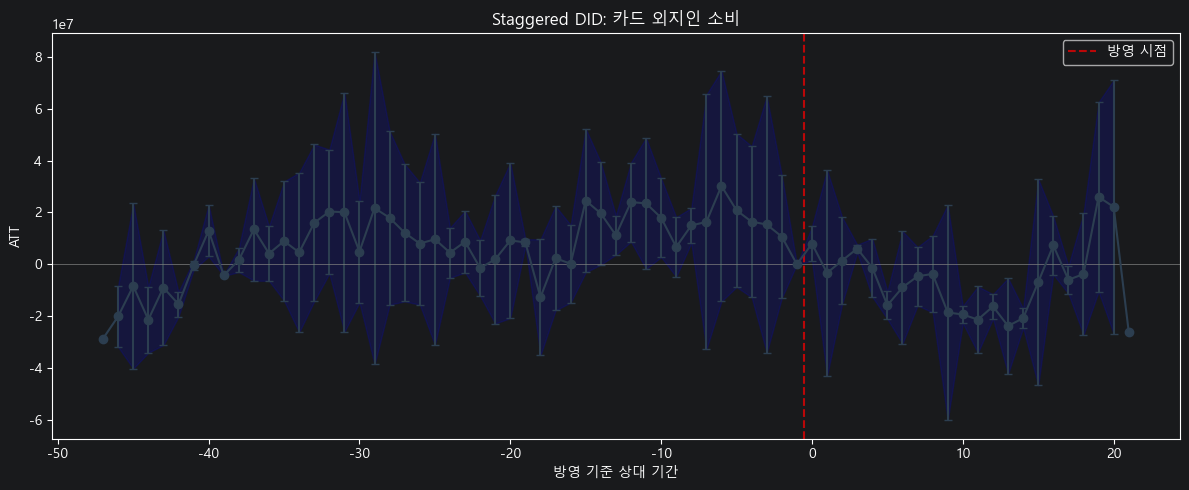

전체 ATT (노출 후 평균): -5,406,252


In [13]:
att = staggered_did(card_panel2, y_col=amt_col, unit_col=dong_col,
                    time_col='time_idx', treatment_time_col='treatment_time')
if len(att) > 0:
    plot_event_study(att, 'Staggered DID: 카드 외지인 소비')
    plt.show()
    overall = att[att['event_time'] >= 0]['att'].mean()
    print(f"전체 ATT (노출 후 평균): {overall:,.0f}")
else:
    print("ATT 추정 실패 — 위 처치군 수가 0이면 동 이름 매핑(config) 확인")

## 5. T맵 방문 — 전 방송 일별 단기효과

관광지→촬영 방송 매핑 후, **각 방송을 자기 방영일 기준으로** 분석 (편중 제거).


In [14]:
dfs = []
for f in sorted(TMAP_DIR.glob('as_tmap_od_*.csv')):
    dfs.append(read_csv_auto(f))
tmap = pd.concat(dfs, ignore_index=True)
tmap['date'] = pd.to_datetime(tmap['drv_ymd'], format='%Y%m%d')
print("T맵:", tmap.shape, "| 기간:", tmap['date'].min().date(), "~", tmap['date'].max().date())

T맵: (623346, 70) | 기간: 2025-01-01 ~ 2025-12-31


In [15]:
import re
# 관광지 키워드 → 그 관광지가 등장한 방송 목록 매핑
spot_keywords = {
    '신정호': ['신정호'], '현충사': ['현충사'], '외암민속마을': ['외암', '민속마을'],
    '온양온천': ['온양온천', '온천'], '곡교천': ['곡교천', '은행나무'],
    '피나클랜드': ['피나클'], '영인산': ['영인산'],
}
def match_spot(name):
    for spot, kws in spot_keywords.items():
        for kw in kws:
            if re.search(kw, str(name)):
                return spot
    return None
tmap['spot'] = tmap['dstn_nm'].apply(match_spot)

# 관광지 → 방송 (locations 촬영지명에 키워드 포함되는 방송)
spot_to_programs = {}
for spot, kws in spot_keywords.items():
    progs = set()
    for _, lr in locations.iterrows():
        if any(re.search(k, str(lr['촬영지명'])) for k in kws):
            progs.add(lr['프로그램명'])
    spot_to_programs[spot] = progs
print("관광지별 연계 방송:")
for s, p in spot_to_programs.items():
    print(f"  {s}: {sorted(p)}")

관광지별 연계 방송:
  신정호: ['뛰어야산다2', '박원숙의 같이삽시다 시즌3', '전국노래자랑 아산시편']
  현충사: ['굿모닝 대한민국', '뛰어야산다2']
  외암민속마을: ['박원숙의 같이삽시다 시즌3']
  온양온천: ['굿모닝 대한민국', '뛰어야산다2', '박원숙의 같이삽시다 시즌3', '황제성의 황제파워']
  곡교천: ['굿모닝 대한민국', '뛰어야산다2', '박원숙의 같이삽시다 시즌3']
  피나클랜드: ['굿모닝 대한민국']
  영인산: ['박원숙의 같이삽시다 시즌3']


In [16]:
def tmap_effect(spot, air_date, pre_days=28, post_days=28):
    """관광지의 방영일 전후 일별 방문 변화 (처치=해당 관광지, 통제=기타)."""
    s = tmap[tmap['spot'] == spot]
    if len(s) == 0 or pd.isna(air_date):
        return None
    daily = s.groupby('date')['vst_cnt'].sum()
    pre = daily[(daily.index >= air_date - pd.Timedelta(days=pre_days)) &
                (daily.index < air_date)].mean()
    post = daily[(daily.index >= air_date) &
                 (daily.index < air_date + pd.Timedelta(days=post_days))].mean()
    if pd.isna(pre) or pre == 0:
        return None
    return {'관광지': spot, '방송효과_방문변화율': (post - pre) / pre * 100,
            '방송전_일평균': pre, '방송후_일평균': post}

# 각 관광지를, 그 관광지가 나온 방송의 방영일 기준으로 분석
tmap_rows = []
for spot, progs in spot_to_programs.items():
    for prog in progs:
        air = AIR.get(prog)
        if pd.isna(air) or air > tmap['date'].max():
            continue
        r = tmap_effect(spot, air)
        if r:
            r['프로그램명'] = prog
            tmap_rows.append(r)

tmap_eff = pd.DataFrame(tmap_rows)
print("=== T맵 방송별·관광지별 단기 방문효과 ===")
display(tmap_eff)

=== T맵 방송별·관광지별 단기 방문효과 ===


,관광지,방송효과_방문변화율,방송전_일평균,방송후_일평균,프로그램명
0,신정호,-41.85,330.36,192.11,박원숙의 같이삽시다 시즌3
1,신정호,-31.21,254.14,174.82,전국노래자랑 아산시편
2,현충사,-33.35,712.79,475.07,굿모닝 대한민국
3,외암민속마을,-64.03,125.39,45.11,박원숙의 같이삽시다 시즌3
4,온양온천,-15.31,239.61,202.93,박원숙의 같이삽시다 시즌3
5,온양온천,-27.56,280.39,203.11,굿모닝 대한민국
6,곡교천,-89.51,304.43,31.93,박원숙의 같이삽시다 시즌3
7,곡교천,-28.31,235.04,168.50,굿모닝 대한민국
8,피나클랜드,-76.26,265.11,62.93,굿모닝 대한민국
9,영인산,-74.33,86.68,22.25,박원숙의 같이삽시다 시즌3


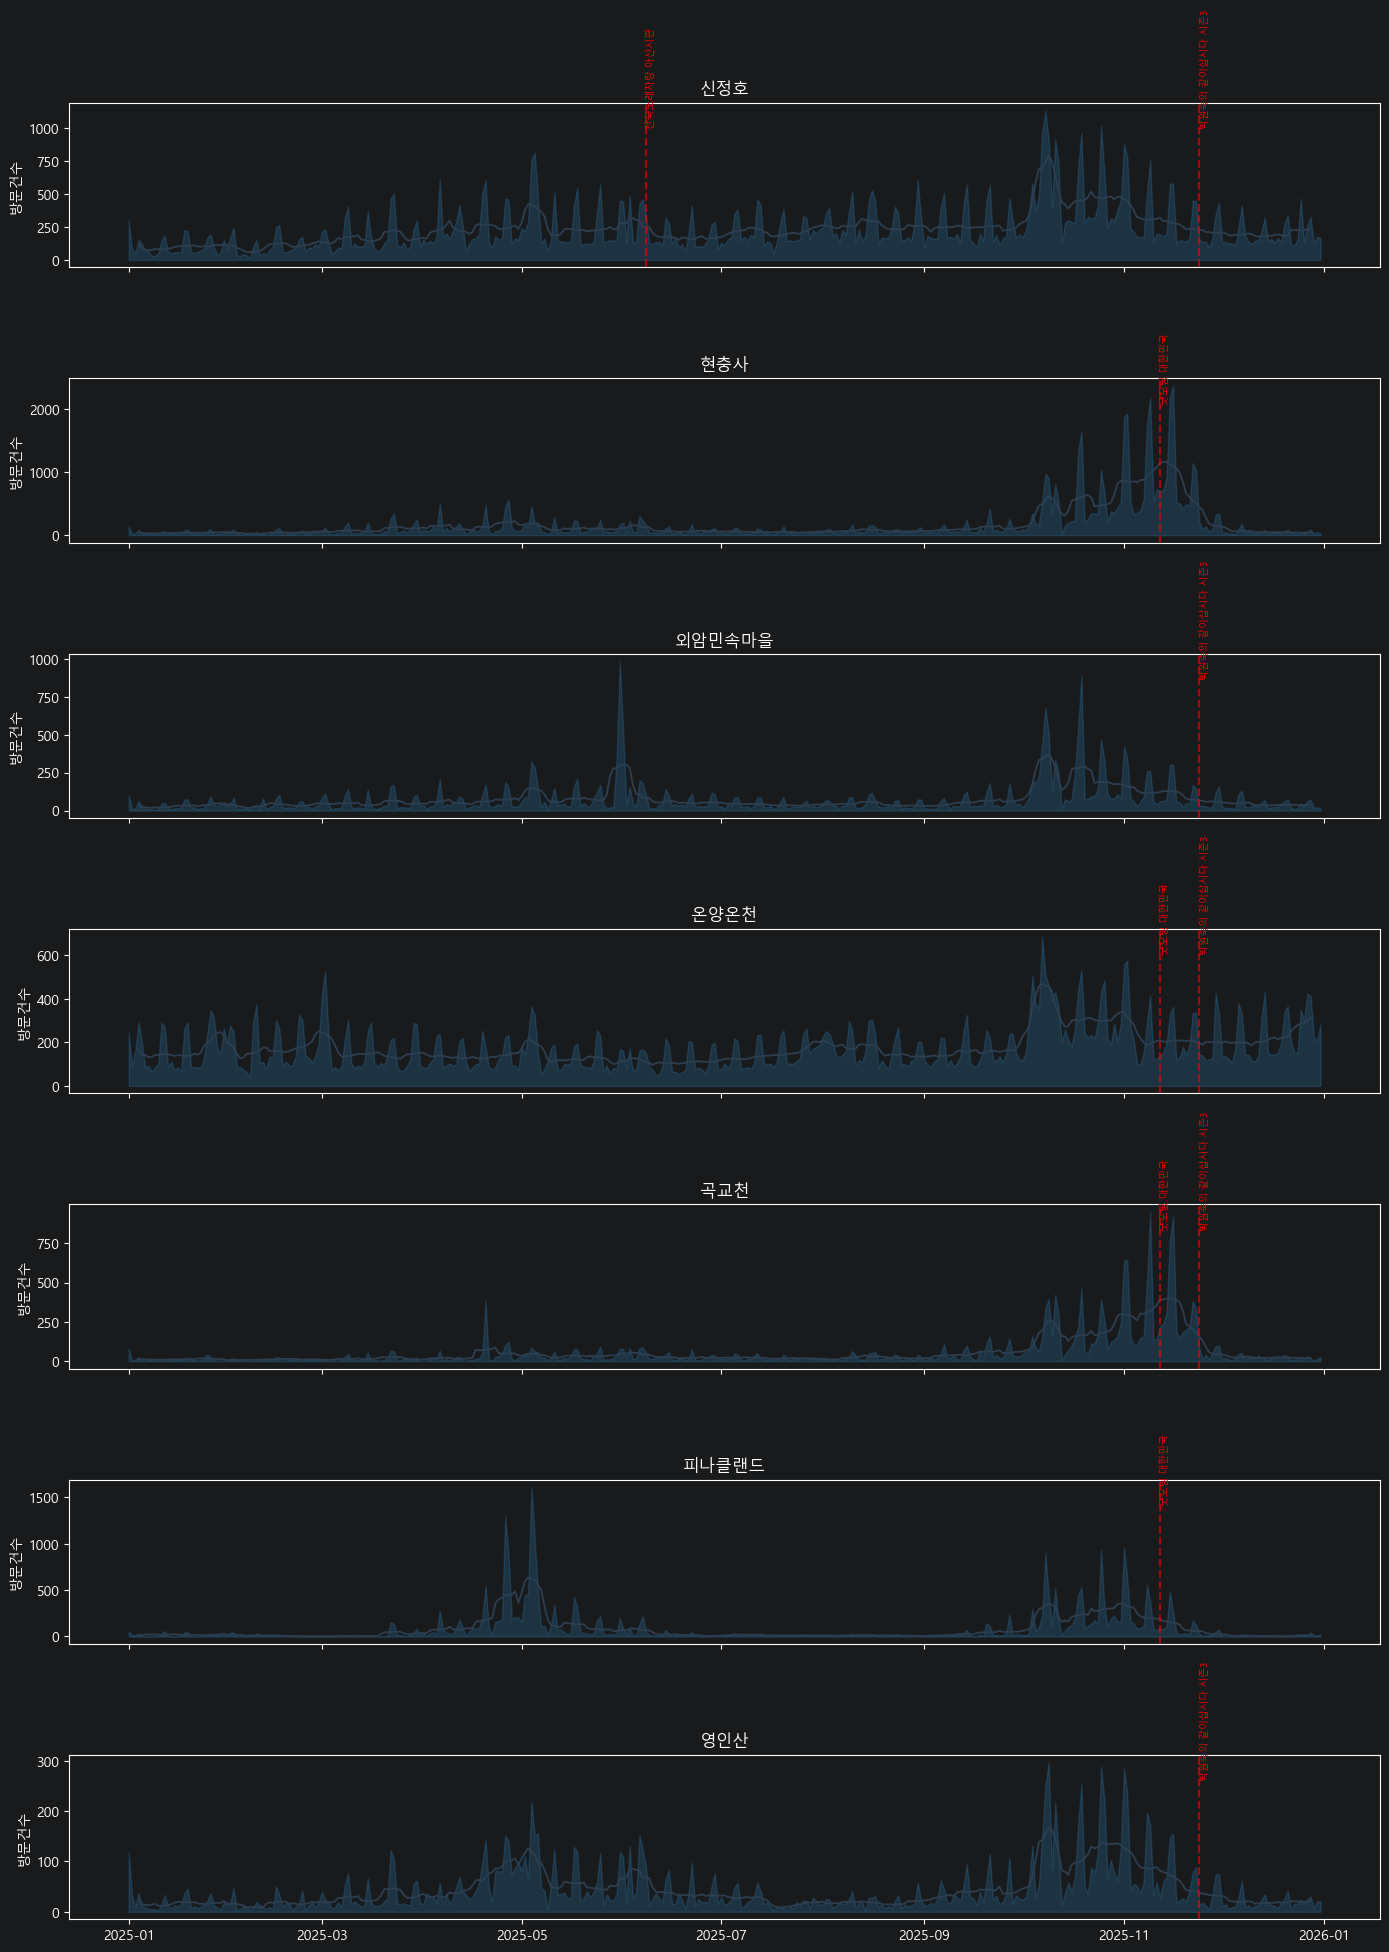

In [17]:
# 관광지별 일별 추이 + 연계 방송 방영일 표시 (전 방송)
spots_present = [s for s in spot_keywords if s in tmap['spot'].values]
fig, axes = plt.subplots(len(spots_present), 1,
                         figsize=(14, 2.8 * len(spots_present)), sharex=True)
if len(spots_present) == 1:
    axes = [axes]
all_air = {p: AIR[p] for p in broadcast['프로그램명'] if pd.notna(AIR.get(p))}
for ax, spot in zip(axes, spots_present):
    daily = tmap[tmap['spot'] == spot].groupby('date')['vst_cnt'].sum()
    ax.fill_between(daily.index, daily.values, alpha=0.2, color='#3498db')
    ax.plot(daily.index, daily.rolling(7, center=True).mean(),
            color='#2c3e50', lw=1.3)
    for prog in spot_to_programs[spot]:
        a = AIR.get(prog)
        if pd.notna(a) and daily.index.min() <= a <= daily.index.max():
            ax.axvline(a, color='red', ls='--', alpha=0.6)
            ax.text(a, ax.get_ylim()[1] * 0.85, prog, fontsize=7,
                    rotation=90, color='red')
    ax.set_title(spot)
    ax.set_ylabel('방문건수')
plt.tight_layout()
plt.show()

## 6. SKT 유입인구 — 가능한 방송만 (커버리지 2026-01~02)

SKT 데이터가 짧아 전 방송엔 못 쓴다. 커버리지에 방영일이 든 방송만 자동 선택.


In [18]:
dong_files = sorted(POP_DIR.glob('*/AS_SKT_SX_AGE_DONG_*.csv'))
print(f"성연령 동 파일 {len(dong_files)}개")
if dong_files:
    skt = pd.concat([read_csv_auto(f) for f in dong_files], ignore_index=True)
    print("SKT:", skt.shape)
    # 컬럼 자동 탐지
    date_c = next((c for c in skt.columns if 'YMD' in c.upper() or c.upper().endswith('DT')), None)
    dong_c = next((c for c in skt.columns if 'DONG' in c.upper() or 'STDG' in c.upper()), None)
    pop_c = next((c for c in skt.columns if 'NOPE' in c.upper() or 'POP' in c.upper()), None)
    print(f"탐지: date={date_c}, dong={dong_c}, pop={pop_c}")
else:
    skt = None

성연령 동 파일 2개
SKT: (2479194, 6)
탐지: date=CRTR_YMD, dong=DPTRE_DONG, pop=None


In [19]:
if skt is not None and date_c and dong_c and pop_c:
    skt['date'] = pd.to_datetime(skt[date_c].astype('Int64').astype(str),
                                 format='%Y%m%d', errors='coerce')
    cov_s, cov_e = skt['date'].min(), skt['date'].max()
    print(f"SKT 커버리지: {cov_s.date()} ~ {cov_e.date()}")

    # 커버리지에 방영일이 든 방송 자동 선택
    skt_targets = [p for p in broadcast['프로그램명']
                   if pd.notna(AIR.get(p)) and cov_s <= AIR[p] <= cov_e]
    print("SKT 분석 가능 방송:", skt_targets)

    skt_rows = []
    for prog in skt_targets:
        air = AIR[prog]
        treated = get_treated_dongs(prog)
        m = skt[dong_c].apply(lambda x: any(t in str(x) for t in treated))
        dt_t = skt[m].groupby('date')[pop_c].sum()
        pre = dt_t[dt_t.index < air].mean()
        post = dt_t[dt_t.index >= air].mean()
        if pd.notna(pre) and pre > 0:
            skt_rows.append({'프로그램명': prog,
                             'SKT유입_변화율': (post - pre) / pre * 100,
                             '전': pre, '후': post})
    display(pd.DataFrame(skt_rows))
else:
    print("SKT 분석 스킵 (파일/컬럼 없음)")

SKT 분석 스킵 (파일/컬럼 없음)


## 7. ★ 핵심: 방송 특성별 효과 차이 (조절효과 분석)

"가수가 나오면? 개그맨이면? 예능이면 다큐면?" 에 답하는 부분.
방송별 효과(카드 CI 상대효과)를 종속변수로, 특성을 설명변수로 결합한다.


In [20]:
# 효과 + 특성 결합 테이블
eff_for_meta = card_eff[card_eff['status'] == 'ok'][
    ['프로그램명', 'CI_상대효과', 'CI_p값', 'CI_유의', 'DID_추정치']].copy()
meta = eff_for_meta.merge(bmeta, on='프로그램명', how='left')

# T맵 효과도 방송 단위로 평균내어 결합 (관광지 여러 개면 평균)
if len(tmap_eff):
    tmap_by_prog = tmap_eff.groupby('프로그램명')['방송효과_방문변화율'].mean().rename('Tmap_방문변화율')
    meta = meta.merge(tmap_by_prog, on='프로그램명', how='left')

print("=== 효과 × 특성 결합 테이블 ===")
display(meta[['프로그램명', '장르범주', '대표유형', '최고인지도', '시청률_pct',
              '노출읍면동수', 'CI_상대효과', 'CI_유의']])

=== 효과 × 특성 결합 테이블 ===


,프로그램명,장르범주,대표유형,최고인지도,시청률_pct,노출읍면동수,CI_상대효과,CI_유의
0,굿모닝 대한민국,교양정보,기타,0.00,0.55,3.00,-10.15,False
1,박원숙의 같이삽시다 시즌3,예능,가수,3.00,3.00,6.00,-24.22,True
2,뛰어야산다2,여행예능,가수,3.00,1.50,2.00,-19.15,True


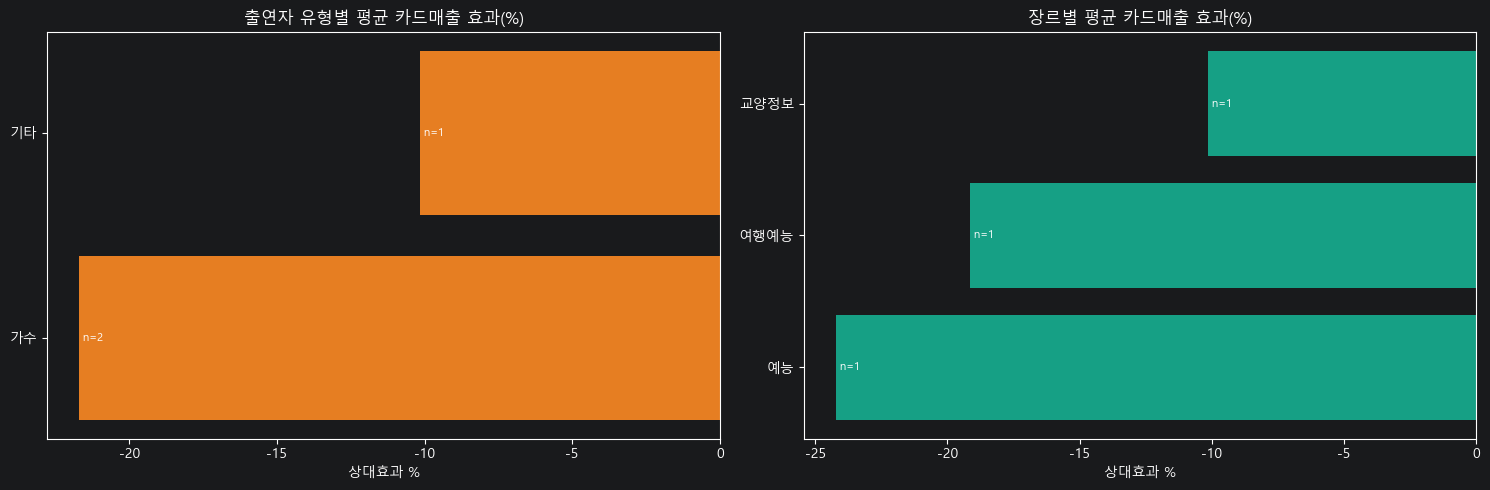

In [21]:
# ---- (a) 출연자 유형별 평균 효과 ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if meta['대표유형'].notna().any():
    by_type = meta.groupby('대표유형')['CI_상대효과'].agg(['mean', 'count'])
    by_type = by_type[by_type['count'] > 0].sort_values('mean')
    axes[0].barh(by_type.index, by_type['mean'], color='#e67e22')
    axes[0].set_title('출연자 유형별 평균 카드매출 효과(%)')
    axes[0].set_xlabel('상대효과 %')
    for i, (idx, row) in enumerate(by_type.iterrows()):
        axes[0].text(row['mean'], i, f" n={int(row['count'])}", va='center', fontsize=8)

if meta['장르범주'].notna().any():
    by_genre = meta.groupby('장르범주')['CI_상대효과'].agg(['mean', 'count'])
    by_genre = by_genre[by_genre['count'] > 0].sort_values('mean')
    axes[1].barh(by_genre.index, by_genre['mean'], color='#16a085')
    axes[1].set_title('장르별 평균 카드매출 효과(%)')
    axes[1].set_xlabel('상대효과 %')
    for i, (idx, row) in enumerate(by_genre.iterrows()):
        axes[1].text(row['mean'], i, f" n={int(row['count'])}", va='center', fontsize=8)
plt.tight_layout()
plt.show()

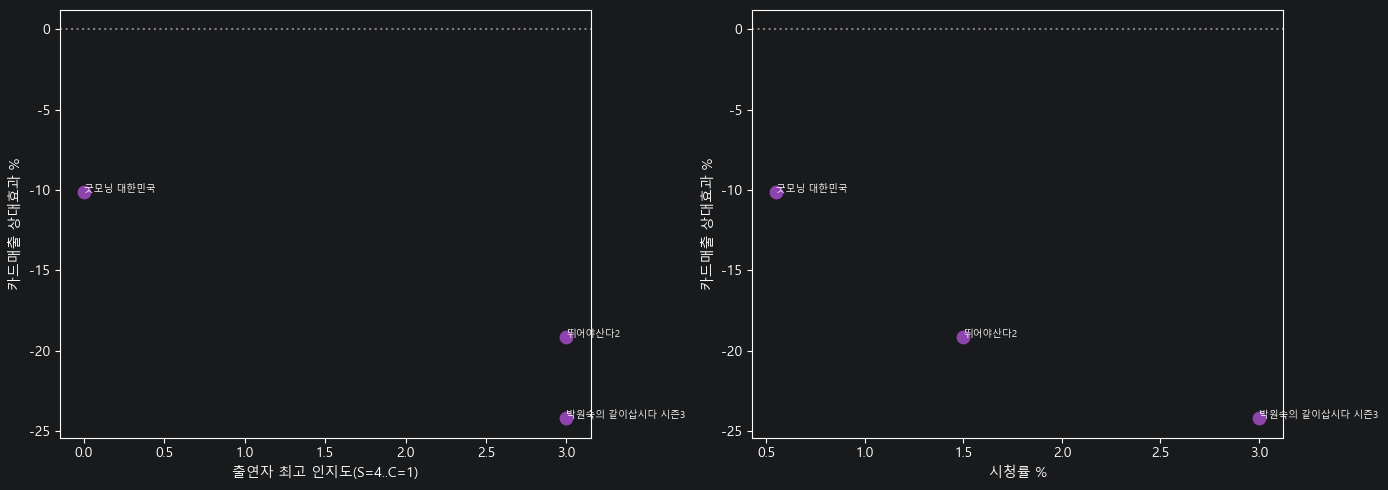

In [22]:
# ---- (b) 인지도/시청률 vs 효과 산점도 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, xcol, xlab in [(axes[0], '최고인지도', '출연자 최고 인지도(S=4..C=1)'),
                       (axes[1], '시청률_pct', '시청률 %')]:
    d = meta.dropna(subset=[xcol, 'CI_상대효과'])
    ax.scatter(d[xcol], d['CI_상대효과'], s=80, color='#8e44ad')
    for _, r in d.iterrows():
        ax.annotate(r['프로그램명'], (r[xcol], r['CI_상대효과']), fontsize=7)
    ax.set_xlabel(xlab); ax.set_ylabel('카드매출 상대효과 %')
    ax.axhline(0, color='gray', ls=':')
plt.tight_layout()
plt.show()

In [23]:
# ---- (c) 메타 회귀: 특성 → 효과 (표본 작으므로 해석은 탐색적) ----
import statsmodels.formula.api as smf

reg_df = meta.dropna(subset=['CI_상대효과']).copy()
reg_df['시청률_pct'] = pd.to_numeric(reg_df['시청률_pct'], errors='coerce')
print(f"메타 회귀 표본 수: {len(reg_df)}개 방송")

if len(reg_df) >= 4:
    # 표본이 매우 작으므로 단변량 위주로
    for formula in ['CI_상대효과 ~ 최고인지도',
                    'CI_상대효과 ~ 노출읍면동수',
                    'CI_상대효과 ~ C(장르범주)']:
        try:
            m = smf.ols(formula, data=reg_df).fit()
            print(f"\n--- {formula} --- R²={m.rsquared:.2f}")
            print(m.params)
        except Exception as e:
            print(f"{formula}: {e}")
else:
    print("표본이 4개 미만 → 회귀 대신 위 (a)(b) 기술통계로 해석 권장")
    print("\n※ 측정가능 방송이 적어 통계적 검정력은 낮음. 실측 6건이 모이면 재실행.")

메타 회귀 표본 수: 3개 방송
표본이 4개 미만 → 회귀 대신 위 (a)(b) 기술통계로 해석 권장

※ 측정가능 방송이 적어 통계적 검정력은 낮음. 실측 6건이 모이면 재실행.


## 8. 미방영 방송 사전 기대효과 예측

측정된 방송들의 특성→효과 관계로, 미방영 3개(비긴어게인·구해줘홈즈·황제파워)의
기대효과를 역추정한다.


In [24]:
pending = bmeta[~bmeta['measurable']].copy()
print("사전평가 대상:", pending['프로그램명'].tolist())

# 측정 표본이 회귀 가능하면 예측, 아니면 유형/장르 평균으로 대입
if 'reg_df' in dir() and len(reg_df) >= 4:
    try:
        model = smf.ols('CI_상대효과 ~ 최고인지도 + 노출읍면동수', data=reg_df).fit()
        pending['예측효과_%'] = model.predict(pending)
    except Exception as e:
        print("회귀 예측 실패:", e)
        pending['예측효과_%'] = np.nan
else:
    # 유형 평균 대입 (대안)
    type_mean = meta.groupby('대표유형')['CI_상대효과'].mean()
    pending['예측효과_%'] = pending['대표유형'].map(type_mean)

display(pending[['프로그램명', '장르범주', '대표유형', '최고인지도',
                 '노출읍면동수', '예측효과_%']])
print("\n※ 표본이 작아 예측은 참고용. 방영 후 실측으로 대체할 것.")

사전평가 대상: ['황제성의 황제파워', '비긴어게인', '구해줘홈즈']


,프로그램명,장르범주,대표유형,최고인지도,노출읍면동수,예측효과_%
6,황제성의 황제파워,라디오,개그맨/MC,2.00,1.00,NaN
7,비긴어게인,음악예능,NaN,0.00,NaN,NaN
8,구해줘홈즈,예능,NaN,0.00,NaN,NaN



※ 표본이 작아 예측은 참고용. 방영 후 실측으로 대체할 것.


## 9. 종합 결과

In [25]:
print("=" * 70)
print("  아산시 방송효과 종합")
print("=" * 70)

final = bmeta[['프로그램명', '연도', '장르범주', '대표유형', 'measurable']].copy()
final = final.merge(card_eff[['프로그램명', 'CI_상대효과', 'CI_유의', 'status']],
                    on='프로그램명', how='left')
if len(tmap_eff):
    final = final.merge(tmap_by_prog, on='프로그램명', how='left')

final['구분'] = np.where(final['measurable'], '실측', '예측대상')
print("\n[실측 방송]")
display(final[final['measurable']].drop(columns='measurable'))
print("\n[사전평가 방송]")
display(final[~final['measurable']].drop(columns='measurable'))

print("""
[해석 가이드]
- CI_상대효과: 방영 후 촬영 읍면동 외지인 소비가 반사실 대비 몇 % 늘었나
- CI_유의=True 인 방송만 효과 신뢰. False/NaN은 효과 불명확 또는 표본부족
- 11월 4개 방송은 겹쳐서 개별 분리 곤란 → 4절 Staggered DID의 통합 ATT로 해석
- 출연자유형·장르별 차이는 7절 참고. 단 측정표본이 적어 탐색적 수준
""")

  아산시 방송효과 종합

[실측 방송]


,프로그램명,연도,장르범주,대표유형,CI_상대효과,CI_유의,status,Tmap_방문변화율,구분
0,전국노래자랑 아산시편,2025,음악예능,가수,NaN,NaN,no_treated_match,-31.21,실측
1,전현무계획2,2025,여행예능,개그맨/MC,NaN,NaN,no_treated_match,NaN,실측
2,굿모닝 대한민국,2025,교양정보,기타,-10.15,False,ok,-41.37,실측
3,6시 내고향,2025,교양정보,기타,NaN,NaN,no_treated_match,NaN,실측
4,박원숙의 같이삽시다 시즌3,2025,예능,가수,-24.22,True,ok,-57.01,실측
5,뛰어야산다2,2025,여행예능,가수,-19.15,True,ok,NaN,실측



[사전평가 방송]


,프로그램명,연도,장르범주,대표유형,CI_상대효과,CI_유의,status,Tmap_방문변화율,구분
6,황제성의 황제파워,2026,라디오,개그맨/MC,NaN,NaN,NaN,NaN,예측대상
7,비긴어게인,2026,음악예능,NaN,NaN,NaN,NaN,NaN,예측대상
8,구해줘홈즈,2026,예능,NaN,NaN,NaN,NaN,NaN,예측대상



[해석 가이드]
- CI_상대효과: 방영 후 촬영 읍면동 외지인 소비가 반사실 대비 몇 % 늘었나
- CI_유의=True 인 방송만 효과 신뢰. False/NaN은 효과 불명확 또는 표본부족
- 11월 4개 방송은 겹쳐서 개별 분리 곤란 → 4절 Staggered DID의 통합 ATT로 해석
- 출연자유형·장르별 차이는 7절 참고. 단 측정표본이 적어 탐색적 수준

